In [1]:
import numpy as np

In [2]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)

    with tarfile.open(tarball_path) as housing_tarball:
        housing_tarball.extractall(path="datasets", filter="data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))



housing_full = load_housing_data()


In [3]:
housing_full.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [4]:
housing_full["income_cat"] = pd.cut(housing_full["median_income"],
bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
labels=[1, 2, 3, 4, 5])

In [5]:
housing_5k = housing_full[:5000]

In [6]:
# help(sklearn)
# dir(sklearn)
# sklearn??

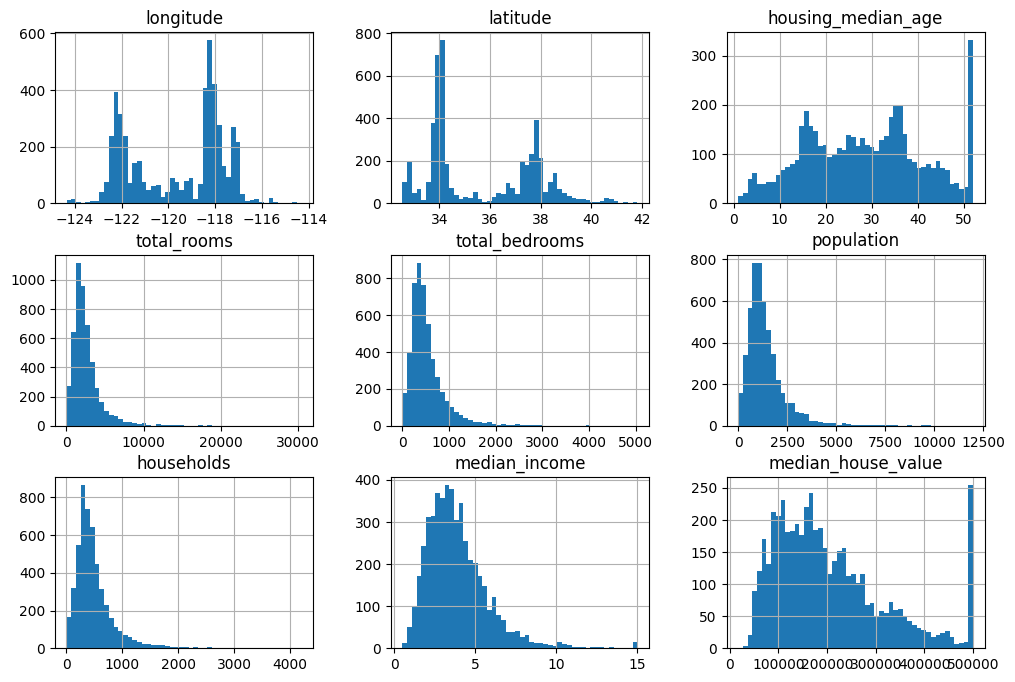

In [7]:
import matplotlib.pyplot as plt
housing_5k.hist(bins=50, figsize=(12, 8))
plt.show()

In [8]:
# 1.
#Try a sup port vec tor ma chine re gres sor (sklearn.svm.SVR) with various hyperparameters, such as
#kernel="linear" (with var i ous val ues for the C hy per pa ram e ter) or kernel="rbf" (with var i ous
#val ues for the C and gamma hy per pa ram e ters). Note that sup port vec tor ma chines don’t scale well to
#large datasets, so you should prob a bly train your model on just the first 5,000 in stances of the train ‐
#ing set and use only 3-fold cross-val i da tion, or else it will take hours. Don’t worry about what the
#hy per pa ram e ters mean for now; these are ex plained in the on line chap ter on SVMs at
#https://homl.info/. How does the best SVR pre dic tor per form?

In [9]:
from sklearn.model_selection import train_test_split
strat_train_set, strat_test_set = train_test_split(housing_5k, test_size=0.2,
random_state=42, stratify=housing_5k["income_cat"])

In [10]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [11]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder


class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [15]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

In [16]:
from sklearn.pipeline import Pipeline
#from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler


def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # feature names out

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler())

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler())
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                                     StandardScaler())

preprocessing = ColumnTransformer([
        ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline(), ["population", "households"]),
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),
        ("geo", cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=default_num_pipeline)

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
param_grid = [
    {'svr__kernel': ['linear'], 'svr__C': [10., 30., 100., 300., 1000.,
                                               3000., 10000., 30000.0]},
    {'svr__kernel': ['rbf'], 'svr__C': [1.0, 3.0, 10., 30., 100., 300.,
                                            1000.0], 'svr__gamma': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]}
]
full_pipeline = Pipeline([
  ("preprocessing", preprocessing),
  ("svr", SVR()),
])
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
                            scoring='neg_root_mean_squared_error')
grid_search.fit(housing, housing_labels)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('bedrooms',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_names_out=<f...
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7c34c3c86ad0>)])),
                                       ('svr', SVR())]),
             param_grid=[{'svr__C': [10.0, 30.0, 100.0, 300.0, 1000.0, 3000.0,
                                     10000.0, 30000.0],
                          'svr__kernel': ['linear']},
                         {'svr__C': [1.0, 3.0, 10.0, 30.0, 100.0, 300.0,
                                     1000.0],
                          'svr__gamma': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0],
                          'svr__kernel': ['rbf']}],
             scoring='neg_root_mean_squared_error')

In [18]:
grid_search.best_params_

{'svr__C': 3000.0, 'svr__kernel': 'linear'}

In [19]:
-grid_search.best_score_

np.float64(75161.84644866791)

In [20]:
# 2. Try re plac ing the GridSearchCV with a RandomizedSearchCV.

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import expon, loguniform

# see https://docs.scipy.org/doc/scipy/reference/stats.html
# for `expon()` and `loguniform()` documentation and more probability distribution functions.

# Note: gamma is ignored when kernel is "linear"
param_distribs = {
        'svr__kernel': ['linear', 'rbf'],
        'svr__C': loguniform(20, 200_000),
        'svr__gamma': expon(scale=1.0),
    }

rnd_search = RandomizedSearchCV(full_pipeline,
                                param_distributions=param_distribs,
                                n_iter=50, cv=3,
                                scoring='neg_root_mean_squared_error',
                                random_state=42)

rnd_search.fit(housing.iloc[:5000], housing_labels.iloc[:5000])


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_names_...
                                                                               <sklearn.compose._column_transformer.make_column_selector object at 0x7c34c3c86ad0>)])),
                                             ('svr', SVR())]),
                   n_iter=50,
                   param_distributions={'svr__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c34c3c85f90>,
                                        'svr__gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c34c40afe10>,
                                        'svr__kernel': ['linear', 'rbf']},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [21]:
svr_rnd_search_rmse = -rnd_search.best_score_
svr_rnd_search_rmse

np.float64(58665.941774756626)

In [22]:
# 3. Try adding a SelectFromModel trans former in the prepa ra tion pipe line to se lect only the most important attributes.
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
drop_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("drop_features", SelectFromModel(estimator=RandomForestRegressor(random_state=42))),
    ("svr", SVR(C=rnd_search.best_params_["svr__C"],
                gamma=rnd_search.best_params_["svr__gamma"],
                kernel=rnd_search.best_params_["svr__kernel"]))
])

selector_rmses = -cross_val_score(drop_pipeline,
                                  housing.iloc[:5000],
                                  housing_labels.iloc[:5000],
                                  scoring="neg_root_mean_squared_error",
                                  cv=3)

pd.Series(selector_rmses).describe()

,0
count,3.000000
mean,69756.088860
std,5570.300229
min,63365.005808
25%,67844.555568
50%,72324.105328
75%,72951.630386
max,73579.155445


In [26]:
svr_rnd_search_rmse = -rnd_search.best_score_
svr_rnd_search_rmse

np.float64(58665.941774756626)

In [32]:
from sklearn.utils.validation import check_array
check_array(housing)

ValueError: Input contains NaN



4. Exercise: Try creating a custom transformer that trains a k-nearest neighbors regressor (sklearn.neighbors.KNeighborsRegressor) in its fit() method, and outputs the model's predictions in its transform() method. The KNN regressor should use only the latitude and longitude as input and predict the median income. Next, add this new transformer to the preprocessing pipeline. This will add a feature representing the smoothed median income over the nearby districts.


In [37]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted
from sklearn.neighbors import KNeighborsRegressor
from pandas.core.frame import DataFrame


class SmoothMedianTransformer(BaseEstimator, TransformerMixin):

  def __init__(self, k, input_features, target): # no *args or **kwargs!
    self.KNR = KNeighborsRegressor(n_neighbors=k)
    self.input_features_ = input_features
    self.target_ = target

  def fit(self, X, y=None):
    if DataFrame != type(X):
      X_df = pd.DataFrame(X)
    else:
      X_df = X.copy()

    self.n_features_in_ = X_df.columns

    self.KNR.fit(X_df[self.input_features_], X_df[self.target_])
     # every estimator stores this in fit()

    return self # always return self!

  def transform(self, X):
    check_is_fitted(self) # looks for learned attributes (with trailing _

    if DataFrame != type(X):
      X_df = pd.DataFrame(X)
    else:
      X_df = X.copy()


    X_df['smoothed_median_income'] = self.KNR.predict(X_df[self.input_features_])
    return X_df



In [38]:
from sklearn.pipeline import make_pipeline
pipe = make_pipeline(
    preprocessing,
    SmoothMedianTransformer(k=10, input_features=[0,1], target=7)
)
pipe.fit_transform(housing)


array([ 0.34531316,  0.06040322, -0.24654425, ..., -0.79154205,
        0.75380033, -0.64470928])

In [27]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
2456,-119.35,36.32,10.0,3817.0,719.0,1686.0,714.0,3.8235,INLAND,3
1541,-122.19,39.53,34.0,2679.0,533.0,1287.0,505.0,2.1650,INLAND,2
1454,-121.85,37.28,17.0,4208.0,954.0,1476.0,904.0,2.3971,<1H OCEAN,2
1196,-118.53,34.18,16.0,7194.0,1976.0,3687.0,1894.0,3.1887,<1H OCEAN,3
3767,-118.39,33.89,30.0,2532.0,464.0,1056.0,419.0,6.3434,<1H OCEAN,5
